# MSCS-634 Final Project: Predicting and Understanding Customer Churn
## A Consolidated Data Mining Pipeline — Deliverables 1–4
**Course:** MSCS-634-B01 — Advanced Big Data and Data Mining
**Dataset:** IBM Telco Customer Churn (7,043 records, 21 attributes)

This notebook consolidates the full project into a single, non-redundant pipeline:
data cleaning and EDA (Deliverable 1), regression modeling (Deliverable 2),
classification, clustering, and association rule mining (Deliverable 3), and a final
cross-technique synthesis (Deliverable 4). Data is loaded and cleaned once; every
later section reuses the same cleaned DataFrame rather than reloading and
re-cleaning it, which each individual deliverable notebook did on its own so it could
run standalone.

**Contents**
1. Dataset Selection and Overview
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Regression Modeling — Predicting `MonthlyCharges`
6. Classification — Predicting `Churn`
7. Clustering — Customer Segmentation
8. Association Rule Mining — Service Bundling Patterns
9. Final Synthesis: Cross-Technique Insights and Recommendations

---

## 1. Dataset Selection and Overview

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
(IBM Sample Data Set)

The dataset contains 7,043 records and 21 attributes describing customers of a
fictional telecommunications company:
- **Demographics:** gender, senior citizen status, partner/dependents
- **Account information:** tenure, contract type, payment method, paperless billing,
  monthly charges, total charges
- **Subscribed services:** phone service, multiple lines, internet service type,
  online security, online backup, device protection, tech support, streaming
  TV/movies
- **Target label:** `Churn` (whether the customer left the company)

**Why this dataset:** it comfortably exceeds the project's minimum size requirement
(500+ records, 8-10+ attributes), mixes numerical and categorical feature types, and
naturally supports every phase of the project — `Churn` as a classification target,
`MonthlyCharges` as a regression target, service attributes for clustering-based
customer segmentation, and the many categorical service columns for association rule
mining.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

df = pd.read_csv("telco.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Data Cleaning

### 2.1 Missing Values

In [3]:
print("Missing values per column (NaN):")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTotal explicit NaNs:", df.isnull().sum().sum())

# No explicit NaNs, but TotalCharges is typed as object -- inspect why.
blank_mask = df["TotalCharges"].str.strip() == ""
print(f"\nBlank/whitespace entries in TotalCharges: {blank_mask.sum()}")
df.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Missing values per column (NaN):
Series([], dtype: int64)

Total explicit NaNs: 0

Blank/whitespace entries in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


These 11 records all have `tenure == 0` — brand-new customers who have not yet
been billed a full cycle, so `TotalCharges` is legitimately unavailable rather than a
data-entry error. The column is converted to numeric and these rows imputed with 0,
consistent with a customer who has not yet accrued charges.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Remaining missing values in TotalCharges:", df["TotalCharges"].isnull().sum())

Remaining missing values in TotalCharges: 0


### 2.2 Duplicates and Inconsistent Categories

In [5]:
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())
print("Fully duplicated rows:", df.duplicated().sum())
# No duplicates found -- no rows need to be dropped on this basis.

Duplicate customerIDs: 0
Fully duplicated rows: 0


In [6]:
# Several service columns encode "no internet/phone service" as a separate
# category instead of simply "No", which is fully implied by
# InternetService/PhoneService and inflates the category count without adding
# information. Collapse these into a single "No" category.
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines"]
for col in service_cols:
    df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

# Recode SeniorCitizen from 0/1 to No/Yes for consistency with other binary columns.
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["SeniorCitizen"].value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

### 2.3 Noisy Data / Outliers

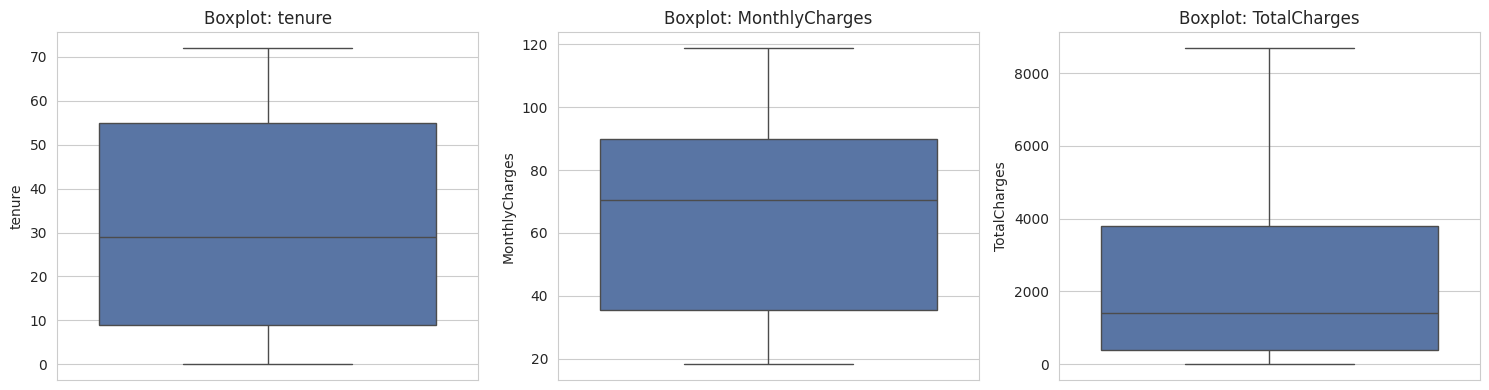

In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

No implausible outliers: `tenure` is bounded between 0 and 72 months (consistent
with a 6-year observation window), and both charge columns fall within a believable
range for monthly telecom billing. No values were removed or capped.

## 3. Exploratory Data Analysis

### 3.1 Target Variable: Churn Distribution

/tmp/ipykernel_484/1787749131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Churn", palette=["#4C72B0", "#DD8452"])


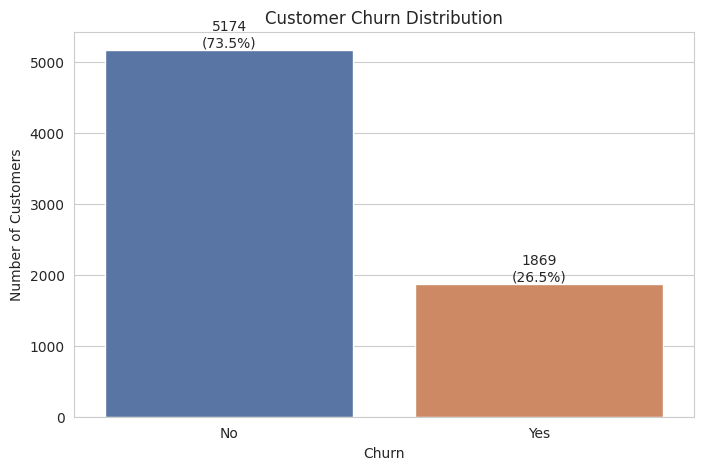

In [8]:
churn_counts = df["Churn"].value_counts(normalize=True) * 100
ax = sns.countplot(data=df, x="Churn", palette=["#4C72B0", "#DD8452"])
for i, v in enumerate(df["Churn"].value_counts()):
    ax.text(i, v + 50, f"{v}\n({churn_counts.iloc[i]:.1f}%)", ha="center")
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
plt.show()

About 26.5% of customers churned versus 73.5% who stayed — a moderate class
imbalance that later informs the classification approach in Section 6 (metrics beyond
raw accuracy, and F1-scored hyperparameter tuning).

### 3.2 Numeric Feature Relationships

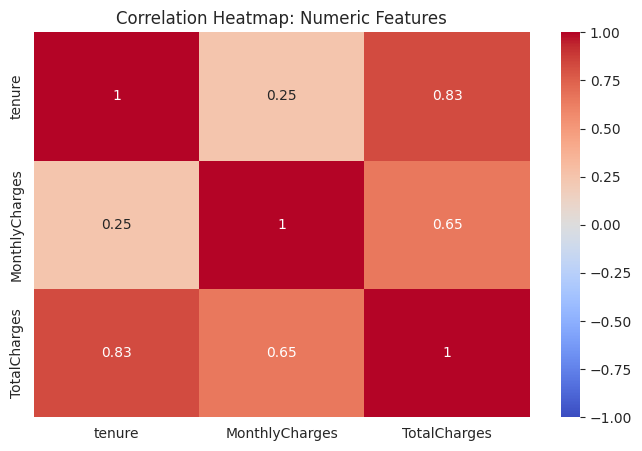

In [9]:
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Numeric Features")
plt.show()

`TotalCharges` is strongly correlated with `tenure` (as expected, since it
accumulates over time) and moderately correlated with `MonthlyCharges`. This
near-collinearity is important ahead of the regression modeling in Section 5, since
including all three as independent predictors would introduce multicollinearity and
data leakage.

### 3.3 Churn by Contract Type, Internet Service, Tenure, and Charges

/tmp/ipykernel_484/1948742648.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[1, 0], palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_484/1948742648.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 1], palette=["#4C72B0", "#DD8452"])


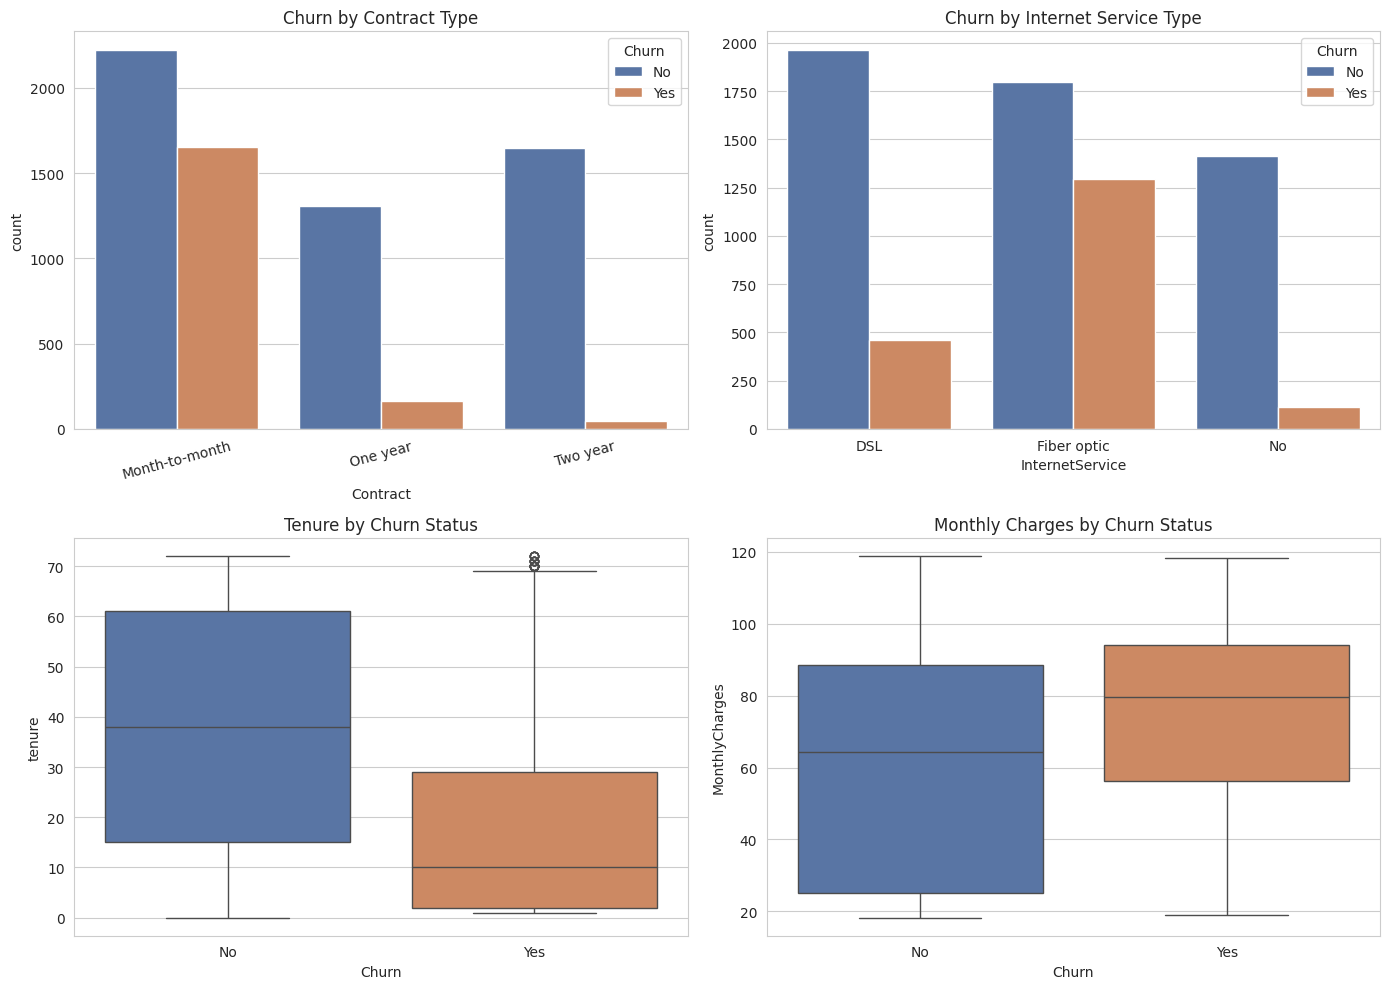

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0, 0], palette=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Churn by Contract Type")
axes[0, 0].tick_params(axis="x", rotation=15)

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[0, 1], palette=["#4C72B0", "#DD8452"])
axes[0, 1].set_title("Churn by Internet Service Type")

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[1, 0], palette=["#4C72B0", "#DD8452"])
axes[1, 0].set_title("Tenure by Churn Status")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 1], palette=["#4C72B0", "#DD8452"])
axes[1, 1].set_title("Monthly Charges by Churn Status")

plt.tight_layout()
plt.show()

Customers on **month-to-month** contracts churn far more than those on one- or
two-year contracts, and **fiber optic** customers churn more than DSL or no-internet
customers. Churners also skew toward **shorter tenure** and **higher monthly
charges**. These four attributes (`Contract`, `InternetService`, `tenure`,
`MonthlyCharges`) are the strongest early churn signals and reappear as top
predictors, cluster separators, and association-rule antecedents in every later
section.

### 3.4 EDA Summary

1. **Class imbalance** (Churn ≈26.5%/73.5%) → informs classification metric choice
   (Section 6).
2. **Multicollinearity** among `tenure`, `MonthlyCharges`, `TotalCharges` → informs
   regression target/predictor choice (Section 5).
3. **Contract type and internet service type** are strong churn signals.
4. **Shorter tenure + higher pricing** correlates with churn.

## 4. Feature Engineering

Deliverable 1's EDA flagged `TotalCharges` as near-collinear with `tenure` and
`MonthlyCharges`. To avoid leakage-prone modeling later, the following features are
engineered once here and reused throughout Sections 5–7:

- **`NumAddOnServices`** — count (0–6) of subscribed add-on services (online
  security, online backup, device protection, tech support, streaming TV, streaming
  movies), condensing six sparse binary columns into one informative count.
- **`HasInternet`** / **`HasPhone`** — binary flags derived from `InternetService`
  and `PhoneService`.
- **`TenureGroup`** — `tenure` binned into five lifecycle stages (0–12, 13–24, 25–48,
  49–60, 61–72 months).
- **`ChurnFlag`** — binary encoding (1/0) of the `Churn` target for modeling.

In [11]:
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["NumAddOnServices"] = (df[addon_cols] == "Yes").sum(axis=1)

df["HasInternet"] = (df["InternetService"] != "No").astype(int)
df["HasPhone"] = (df["PhoneService"] == "Yes").astype(int)

bins = [-1, 12, 24, 48, 60, 72]
labels = ["0-12", "13-24", "25-48", "49-60", "61-72"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)

df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

df[["NumAddOnServices", "TenureGroup", "HasInternet", "HasPhone", "ChurnFlag"]].head()

,NumAddOnServices,TenureGroup,HasInternet,HasPhone,ChurnFlag
0,1,0-12,1,0,0
1,2,25-48,1,1,0
2,2,0-12,1,1,1
3,3,25-48,1,0,0
4,0,0-12,1,1,1


## 5. Regression Modeling — Predicting `MonthlyCharges`

**Target:** `MonthlyCharges`. Since `TotalCharges` is a poor, leakage-prone
regression target (near-collinear with `tenure`/`MonthlyCharges`, Section 3.2), this
section instead predicts `MonthlyCharges` from a customer's subscribed services,
contract terms, and demographics — a target with genuine predictive structure and
clear business relevance (pricing/plan design). `TotalCharges` and raw `tenure` are
excluded from the predictors to avoid leakage.

Three regression models are trained on an 80/20 train/test split with standardized
features: **Multiple Linear Regression** (baseline), **Ridge Regression** (L2,
`alpha=1.0`), and **Lasso Regression** (L1, `alpha=0.1`).

In [12]:
reg_feature_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling",
    "PaymentMethod", "NumAddOnServices", "HasInternet", "HasPhone", "TenureGroup",
]

X_reg = pd.get_dummies(df[reg_feature_cols], drop_first=True)
y_reg = df["MonthlyCharges"]
print(f"Predictor matrix shape after one-hot encoding: {X_reg.shape}")

Predictor matrix shape after one-hot encoding: (7043, 27)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_scaler = StandardScaler()
Xr_train_scaled = reg_scaler.fit_transform(Xr_train)
Xr_test_scaled = reg_scaler.transform(Xr_test)

print(f"Training set: {Xr_train.shape[0]} rows | Test set: {Xr_test.shape[0]} rows")

Training set: 5634 rows | Test set: 1409 rows


In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000),
}

reg_results = []
reg_predictions = {}
for name, model in reg_models.items():
    model.fit(Xr_train_scaled, yr_train)
    y_pred = model.predict(Xr_test_scaled)
    reg_predictions[name] = y_pred

    r2 = r2_score(yr_test, y_pred)
    mse = mean_squared_error(yr_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yr_test, y_pred)
    cv_scores = cross_val_score(model, Xr_train_scaled, yr_train, cv=5, scoring="r2")

    reg_results.append({
        "Model": name, "R2 (test)": r2, "RMSE (test)": rmse, "MAE (test)": mae,
        "CV R2 (mean)": cv_scores.mean(), "CV R2 (std)": cv_scores.std(),
    })

reg_results_df = pd.DataFrame(reg_results).set_index("Model")
reg_results_df

,R2 (test),RMSE (test),MAE (test),CV R2 (mean),CV R2 (std)
Model,,,,,
Linear Regression,0.998780,1.051190,0.788274,0.998842,0.000051
Ridge Regression,0.998779,1.051286,0.788299,0.998842,0.000051
Lasso Regression,0.998740,1.068121,0.806883,0.998816,0.000041


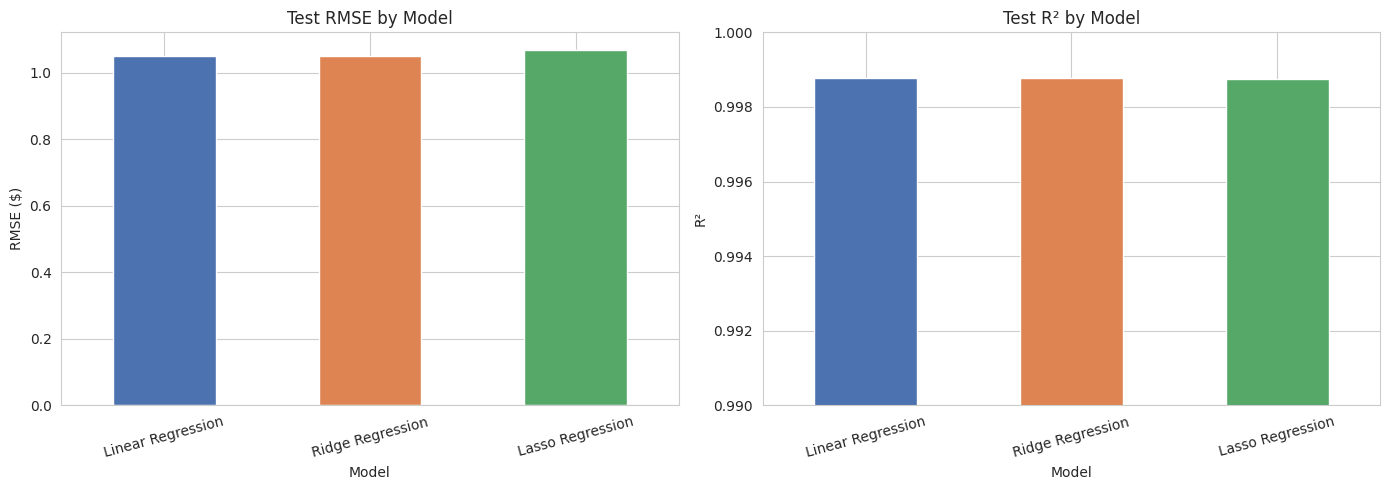

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_results_df["RMSE (test)"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Test RMSE by Model")
axes[0].set_ylabel("RMSE ($)")
axes[0].tick_params(axis="x", rotation=15)

reg_results_df["R2 (test)"].plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Test R\u00b2 by Model")
axes[1].set_ylabel("R\u00b2")
axes[1].set_ylim(0.99, 1.0)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

All three models explain over 99.8% of the variance in `MonthlyCharges`, with
RMSE around $1 (on a variable ranging \$18–\$119). This is expected, not suspicious:
`MonthlyCharges` is nearly a deterministic sum of the prices of a customer's
subscribed services. Cross-validation R² closely tracks test R² for every model,
confirming the fit generalizes rather than reflecting one lucky train/test split.
**Ridge Regression** is the preferred model — statistically tied with Linear
Regression on accuracy, but its L2 penalty gives more stable coefficients if
retrained on new data.

Lasso zeroed out 18 of 27 features.


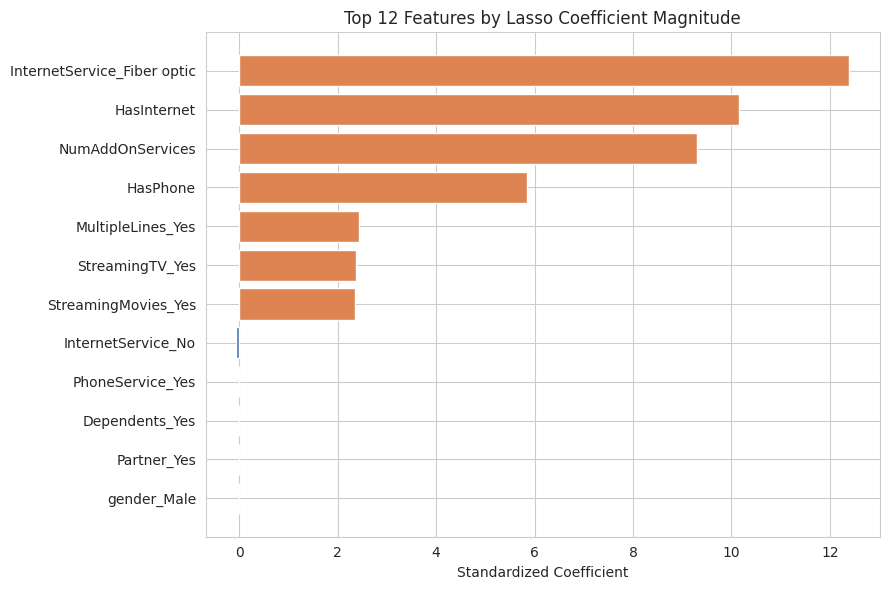

In [16]:
lasso_model = reg_models["Lasso Regression"]
coef_df = pd.DataFrame({
    "Feature": X_reg.columns,
    "Coefficient": lasso_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

n_zero = (coef_df["Coefficient"] == 0).sum()
print(f"Lasso zeroed out {n_zero} of {len(coef_df)} features.")

top_features = coef_df.head(12)
plt.figure(figsize=(9, 6))
colors = ["#DD8452" if c > 0 else "#4C72B0" for c in top_features["Coefficient"]]
plt.barh(top_features["Feature"][::-1], top_features["Coefficient"][::-1], color=colors[::-1])
plt.title("Top 12 Features by Lasso Coefficient Magnitude")
plt.xlabel("Standardized Coefficient")
plt.tight_layout()
plt.show()

The largest positive drivers of `MonthlyCharges` are fiber-optic internet and
add-on services, while having no internet service is the strongest negative driver —
consistent with how telecom pricing plans are structured. **Implication carried
forward:** since `MonthlyCharges` mostly re-encodes the service columns, it should be
used cautiously as a *predictor* of churn in Section 6; `NumAddOnServices` and
`Contract` type are more compact, non-redundant signals.

## 6. Classification — Predicting `Churn`

**Target:** `Churn` (binary, encoded as `ChurnFlag`). Predictors are the
demographic, account, contract, and service columns plus the engineered features
from Section 4 (`customerID` and `Churn` itself excluded).

Two models are built: a **Decision Tree Classifier** (interpretable, handles mixed
feature types well) and **k-Nearest Neighbors** (a distance-based contrast to the
tree's axis-aligned splits).

In [17]:
clf_drop_cols = ["customerID", "Churn", "MonthlyCharges", "TotalCharges", "ChurnFlag"]
clf_feature_cols = [c for c in df.columns if c not in clf_drop_cols and c != "Cluster"]

X_clf = pd.get_dummies(df[clf_feature_cols], drop_first=True)
y_clf = df["ChurnFlag"]
print(f"Predictor matrix shape after one-hot encoding: {X_clf.shape}")

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

clf_scaler = StandardScaler()
Xc_train_scaled = clf_scaler.fit_transform(Xc_train)
Xc_test_scaled = clf_scaler.transform(Xc_test)

print(f"Training set: {Xc_train.shape[0]} rows | Test set: {Xc_test.shape[0]} rows")
print(f"Train churn rate: {yc_train.mean():.1%} | Test churn rate: {yc_test.mean():.1%}")

Predictor matrix shape after one-hot encoding: (7043, 28)
Training set: 5634 rows | Test set: 1409 rows
Train churn rate: 26.5% | Test churn rate: 26.5%


**Note on `MonthlyCharges`/`TotalCharges` as predictors:** consistent with the
regression findings in Section 5, `MonthlyCharges` and `TotalCharges` are excluded
from the classification predictors here — since `MonthlyCharges` is nearly a
deterministic function of the service columns, including it would be redundant with
(and could mask the interpretability of) the underlying service and contract
features that actually drive both price and churn.

### 6.1 Baseline Models

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5)
dt_model.fit(Xc_train_scaled, yc_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(Xc_train_scaled, yc_train)

print("Baseline Decision Tree and k-NN models trained.")

Baseline Decision Tree and k-NN models trained.


### 6.2 Hyperparameter Tuning (Decision Tree)

`GridSearchCV` with 5-fold cross-validation tunes the Decision Tree over
`max_depth`, `min_samples_leaf`, and `criterion`, optimizing for **F1 score** rather
than accuracy — F1 balances precision and recall, which matters since churners are
the minority class (~26.5%) and accuracy alone can be misleadingly high from simply
predicting "No churn" most of the time.

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring="f1", n_jobs=-1,
)
grid_search.fit(Xc_train_scaled, yc_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated F1 score: {grid_search.best_score_:.4f}")

dt_tuned = grid_search.best_estimator_

Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1}
Best cross-validated F1 score: 0.5875


### 6.3 Evaluation: Confusion Matrix, ROC Curve, Accuracy/F1

In [20]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, f1_score

clf_models = {
    "Decision Tree (baseline)": dt_model,
    "Decision Tree (tuned)": dt_tuned,
    "k-NN (k=5)": knn_model,
}

clf_eval_results = []
roc_data = {}
for name, model in clf_models.items():
    y_pred = model.predict(Xc_test_scaled)
    y_proba = model.predict_proba(Xc_test_scaled)[:, 1]

    acc = accuracy_score(yc_test, y_pred)
    f1 = f1_score(yc_test, y_pred)
    fpr, tpr, _ = roc_curve(yc_test, y_proba)
    roc_auc = auc(fpr, tpr)

    roc_data[name] = (fpr, tpr, roc_auc)
    clf_eval_results.append({"Model": name, "Accuracy": acc, "F1 Score": f1, "ROC AUC": roc_auc})

clf_eval_df = pd.DataFrame(clf_eval_results).set_index("Model")
clf_eval_df

,Accuracy,F1 Score,ROC AUC
Model,,,
Decision Tree (baseline),0.789212,0.576320,0.823682
Decision Tree (tuned),0.750887,0.558491,0.788594
k-NN (k=5),0.745919,0.509589,0.761995


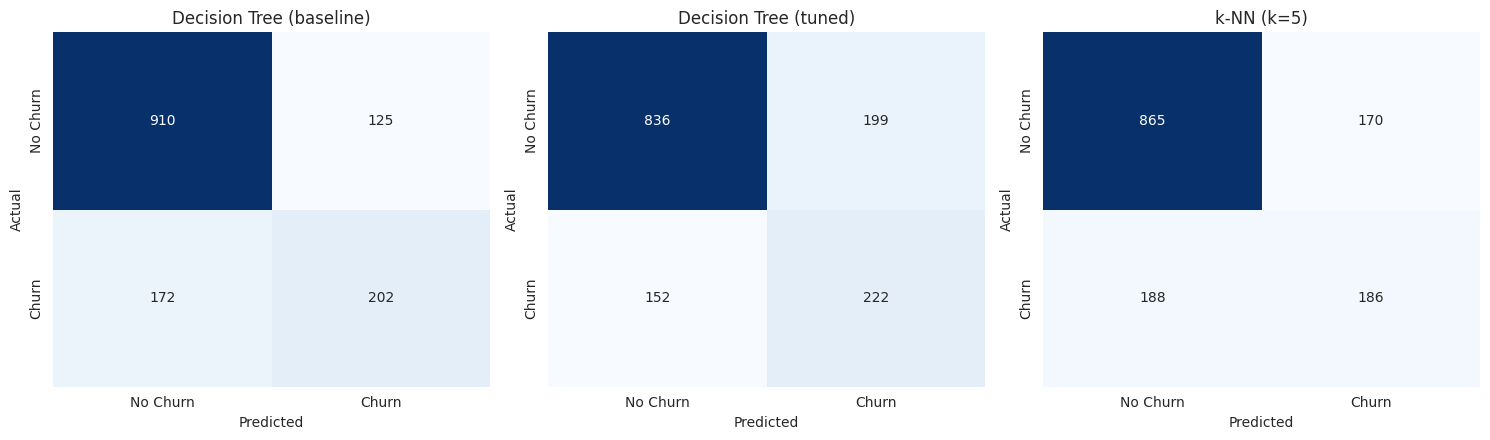

In [21]:
fig, axes = plt.subplots(1, len(clf_models), figsize=(5 * len(clf_models), 4.5))
for ax, (name, model) in zip(axes, clf_models.items()):
    y_pred = model.predict(Xc_test_scaled)
    cm = confusion_matrix(yc_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

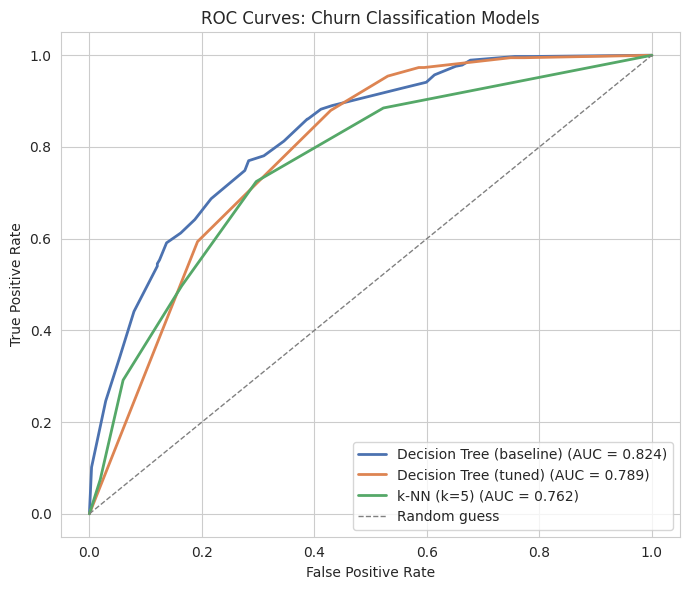

In [22]:
plt.figure(figsize=(7, 6))
colors = ["#4C72B0", "#DD8452", "#55A868"]
for (name, (fpr, tpr, roc_auc)), color in zip(roc_data.items(), colors):
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Churn Classification Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Both Decision Tree variants outperform k-NN on ROC AUC — tree splits align
naturally with strongly predictive categorical features here (`Contract`,
`InternetService`), which k-NN's raw Euclidean distance in one-hot-encoded space
captures less cleanly. The **tuned** tree scores slightly lower than the untuned
baseline on this particular test split, even though grid search selected it as the
best *cross-validated* F1 on the training folds — the grid search chose a shallower
tree (less prone to overfitting a specific sample) based on stronger evidence
(5-fold CV) than the baseline's arbitrary depth choice, a useful reminder that tuning
optimizes for expected generalization, not for beating one specific split.

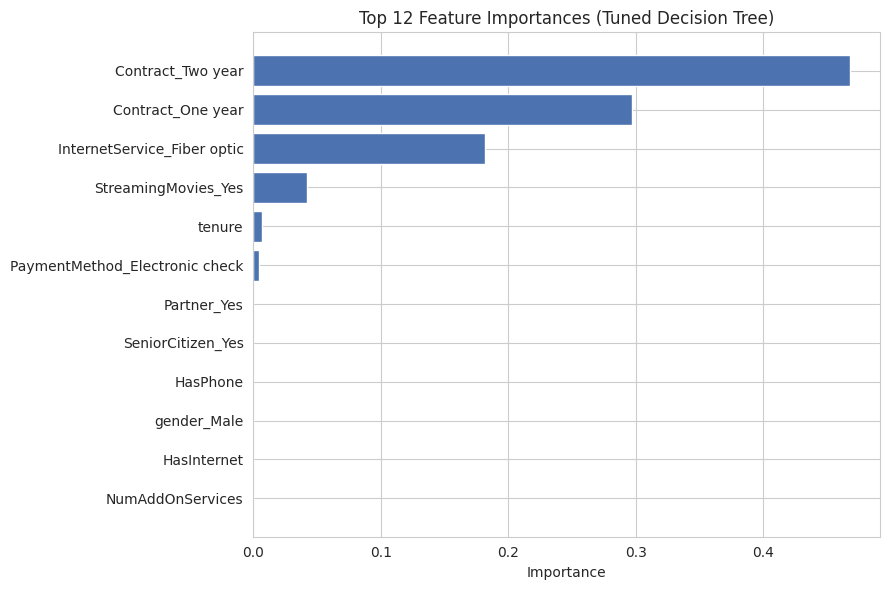

In [23]:
importances = pd.DataFrame({
    "Feature": X_clf.columns,
    "Importance": dt_tuned.feature_importances_
}).sort_values("Importance", ascending=False).head(12)

plt.figure(figsize=(9, 6))
plt.barh(importances["Feature"][::-1], importances["Importance"][::-1], color="#4C72B0")
plt.title("Top 12 Feature Importances (Tuned Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Clustering — Customer Segmentation

**Goal:** group customers into behaviorally similar segments using account and
service attributes, independent of the churn label, to see whether natural segments
align with churn risk. Features used: `tenure`, `MonthlyCharges`,
`NumAddOnServices`, `HasInternet`, `HasPhone`, and one-hot encoded `Contract`.

K-Means is used, with `k` chosen via the elbow method and confirmed with silhouette
score.

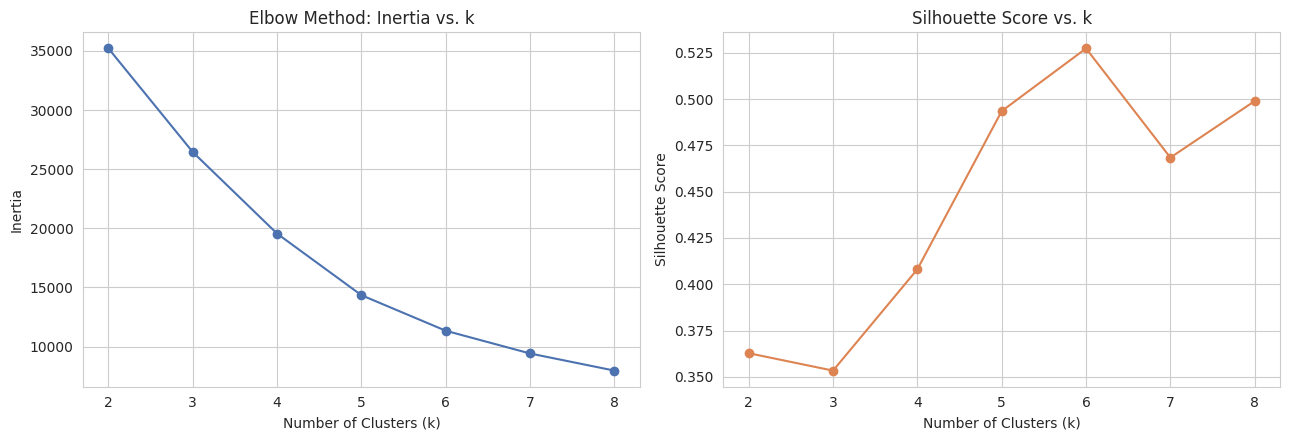

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ["tenure", "MonthlyCharges", "NumAddOnServices", "HasInternet", "HasPhone"]
cluster_cat = pd.get_dummies(df["Contract"], prefix="Contract", drop_first=True)
X_cluster = pd.concat([df[cluster_features], cluster_cat], axis=1)

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method: Inertia vs. k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

The elbow bends around **k = 4**, with a favorable silhouette score there
relative to larger `k`, so 4 clusters are used for the final segmentation.

Final silhouette score (k=4): 0.408


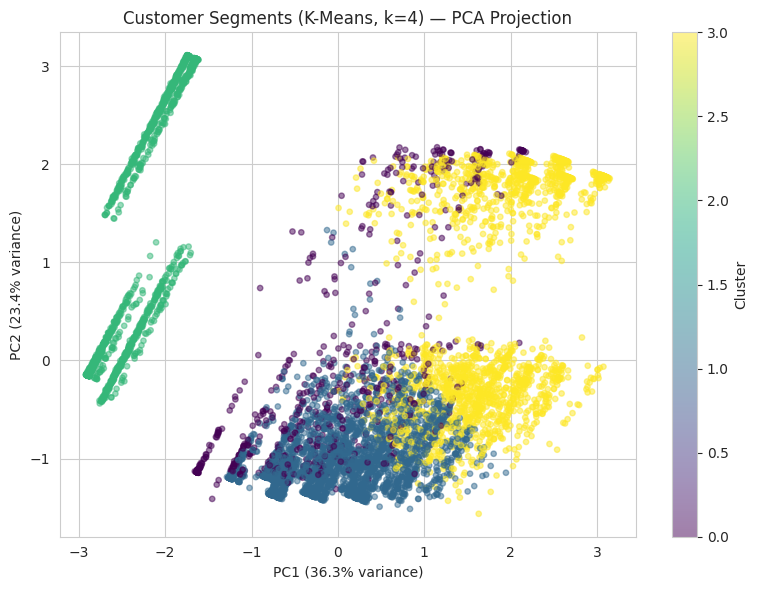

In [25]:
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_cluster_scaled)
print(f"Final silhouette score (k={K_FINAL}): {silhouette_score(X_cluster_scaled, df['Cluster']):.3f}")

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.5, s=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title(f"Customer Segments (K-Means, k={K_FINAL}) \u2014 PCA Projection")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

In [26]:
cluster_profile = df.groupby("Cluster").agg(
    AvgTenure=("tenure", "mean"),
    AvgMonthlyCharges=("MonthlyCharges", "mean"),
    AvgNumAddOns=("NumAddOnServices", "mean"),
    ChurnRate=("ChurnFlag", "mean"),
    Size=("ChurnFlag", "size"),
).round(2)
cluster_profile["ChurnRate"] = (cluster_profile["ChurnRate"] * 100).round(1)
cluster_profile

,AvgTenure,AvgMonthlyCharges,AvgNumAddOns,ChurnRate,Size
Cluster,,,,,
0,31.74,42.03,2.56,25.0,682
1,16.05,75.17,1.60,47.0,2835
2,30.55,21.08,0.00,7.0,1526
3,57.11,91.09,4.04,13.0,2000


**Cluster interpretation:**
- **Highest-churn segment** (short tenure ≈16 mo, \$75/mo, only 1.6 add-ons, **47%
  churn**): newer customers already paying a mid-to-high bill without much bundled
  value yet — the clearest retention-campaign target.
- **Loyal power users** (tenure ≈57 mo, \$91/mo, 4.0 add-ons, 13% churn): highest
  spend but heavily bundled, and the lowest-risk high-value segment.
- **Low-cost, low-churn** (tenure ≈31 mo, \$21/mo, 0 add-ons, **7% churn**, lowest of
  all): mostly no-internet-service customers with a small, predictable bill —
  showing that "few add-ons" alone is not a churn driver.
- **Mid-tenure, moderate bundle** (tenure ≈32 mo, \$42/mo, 2.6 add-ons, 25% churn ≈
  baseline): an unremarkable middle segment.

Entirely unsupervised — with no access to the `Churn` label — K-Means independently
converges on the same signal the classifier found: **short tenure combined with a
non-trivial bill relative to service value**, not add-on count alone, separates
low-risk from high-risk customers.

## 8. Association Rule Mining — Service Bundling Patterns

**Goal:** find which subscribed services co-occur, and whether particular
combinations associate with churn — useful for bundle design and targeted retention.
Each customer's services (plus `Churn` and `Contract`) are encoded as a binary
"basket," and **Apriori** mines frequent itemsets and association rules, ranked by
**lift**. `PhoneService` is excluded — at ~90% adoption it is near-universal and
would dominate rules with trivially high confidence but little insight.

In [27]:
from mlxtend.frequent_patterns import apriori, association_rules

basket_cols = {
    "MultipleLines": "MultipleLines",
    "OnlineSecurity": "OnlineSecurity", "OnlineBackup": "OnlineBackup",
    "DeviceProtection": "DeviceProtection", "TechSupport": "TechSupport",
    "StreamingTV": "StreamingTV", "StreamingMovies": "StreamingMovies",
    "PaperlessBilling": "PaperlessBilling",
}

basket = pd.DataFrame(index=df.index)
for col, label in basket_cols.items():
    basket[label] = (df[col] == "Yes")

for val in ["DSL", "Fiber optic"]:
    basket[f"Internet_{val}"] = (df["InternetService"] == val)
for val in df["Contract"].unique():
    basket[f"Contract_{val}"] = (df["Contract"] == val)
basket["Churn_Yes"] = (df["Churn"] == "Yes")

print(f"Basket shape: {basket.shape[0]} transactions, {basket.shape[1]} items")

frequent_itemsets = apriori(basket, min_support=0.15, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
rules = rules.sort_values("lift", ascending=False)
print(f"Frequent itemsets: {len(frequent_itemsets)} | Rules: {len(rules)}")

rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

Basket shape: 7043 transactions, 14 items
Frequent itemsets: 79 | Rules: 174


,antecedents,consequents,support,confidence,lift
112,"frozenset({DeviceProtection, StreamingTV})",frozenset({StreamingMovies}),0.178049,0.800255,2.063030
113,frozenset({StreamingMovies}),"frozenset({DeviceProtection, StreamingTV})",0.178049,0.459004,2.063030
172,frozenset({Churn_Yes}),"frozenset({Internet_Fiber optic, Contract_Mont...",0.164987,0.621723,2.057704
169,"frozenset({Internet_Fiber optic, Contract_Mont...",frozenset({Churn_Yes}),0.164987,0.546053,2.057704
110,"frozenset({StreamingMovies, DeviceProtection})",frozenset({StreamingTV}),0.178049,0.786207,2.045532
115,frozenset({StreamingTV}),"frozenset({StreamingMovies, DeviceProtection})",0.178049,0.463243,2.045532
68,"frozenset({StreamingMovies, MultipleLines})",frozenset({StreamingTV}),0.171660,0.759899,1.977086
73,frozenset({StreamingTV}),"frozenset({StreamingMovies, MultipleLines})",0.171660,0.446620,1.977086
70,"frozenset({MultipleLines, StreamingTV})",frozenset({StreamingMovies}),0.171660,0.766646,1.976385
71,frozenset({StreamingMovies}),"frozenset({MultipleLines, StreamingTV})",0.171660,0.442533,1.976385


In [28]:
churn_rules = rules[rules["consequents"].apply(lambda x: "Churn_Yes" in x)]
churn_rules = churn_rules.sort_values("lift", ascending=False)
churn_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
169,"frozenset({Internet_Fiber optic, Contract_Mont...",frozenset({Churn_Yes}),0.164987,0.546053,2.057704
163,"frozenset({Contract_Month-to-month, PaperlessB...",frozenset({Churn_Yes}),0.177339,0.482985,1.820046
159,frozenset({Internet_Fiber optic}),"frozenset({Churn_Yes, PaperlessBilling})",0.151640,0.344961,1.735401
157,"frozenset({Internet_Fiber optic, PaperlessBill...",frozenset({Churn_Yes}),0.151640,0.445929,1.680406
173,frozenset({Contract_Month-to-month}),"frozenset({Internet_Fiber optic, Churn_Yes})",0.164987,0.299871,1.628366
165,frozenset({Contract_Month-to-month}),"frozenset({Churn_Yes, PaperlessBilling})",0.177339,0.322323,1.621513
66,frozenset({Contract_Month-to-month}),frozenset({Churn_Yes}),0.234985,0.427097,1.609440
171,frozenset({Internet_Fiber optic}),"frozenset({Contract_Month-to-month, Churn_Yes})",0.164987,0.375323,1.597220
64,frozenset({Internet_Fiber optic}),frozenset({Churn_Yes}),0.184154,0.418928,1.578656
161,frozenset({PaperlessBilling}),"frozenset({Internet_Fiber optic, Churn_Yes})",0.151640,0.256054,1.390429


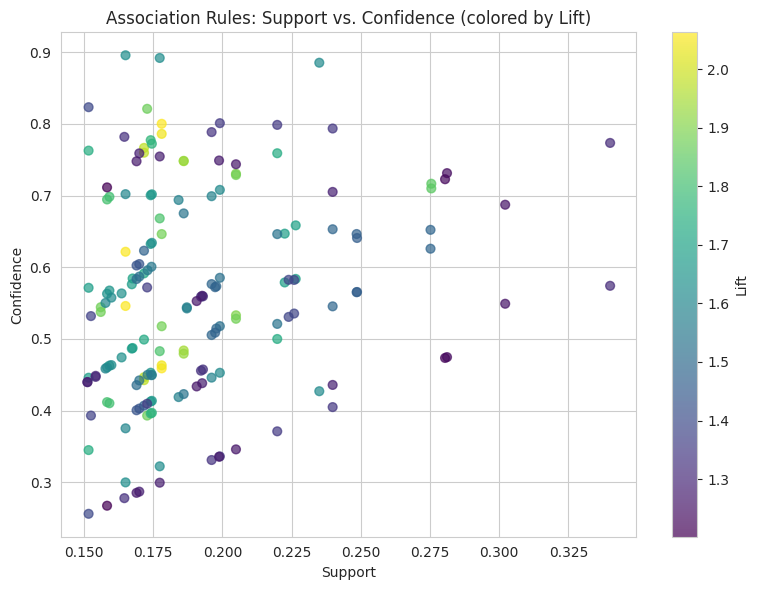

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(rules["support"], rules["confidence"], c=rules["lift"], cmap="viridis", alpha=0.7, s=40)
plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs. Confidence (colored by Lift)")
plt.tight_layout()
plt.show()

**Pattern mining insights:**
- `{Month-to-month contract, Fiber optic internet} → Churn=Yes` is the top
  churn-associated rule (lift ≈2.06) — customers on this combination churn at more
  than double the base rate.
- Streaming service pairs (`StreamingTV` + `DeviceProtection` → `StreamingMovies`,
  lift ≈2.06) reveal a clear cross-sell bundling pattern among fiber/streaming
  customers.
- **Real-world application:** target the high-lift churn antecedents (month-to-month,
  fiber-only, no add-ons) with bundle discounts or contract-upgrade incentives, and
  use the streaming co-occurrence pattern to design better upsell bundles.

## 9. Final Synthesis: Cross-Technique Insights and Recommendations

### Summary of Results by Technique

| Technique | Key Result |
|---|---|
| Regression (§5) | Ridge Regression best; R² ≈0.999, RMSE ≈$1 predicting `MonthlyCharges` from services/contract |
| Classification (§6) | Decision Tree (baseline) best ROC AUC ≈0.83; tuned tree AUC ≈0.79, k-NN AUC ≈0.77 |
| Clustering (§7) | K-Means k=4; churn ranges from 7% (low-cost, low-churn segment) to 47% (short-tenure, thin-bundle segment) |
| Association Rules (§8) | Month-to-month + fiber-optic → churn, lift ≈2.06 |

### Cross-Technique Consistency

All four techniques independently converge on the same underlying story: **churn
risk tracks short tenure and weak commitment (month-to-month contracts, thin service
bundles) rather than the bill amount by itself.** Regression shows price is nearly a
deterministic function of services, not an independent risk factor. Classification
ranks `Contract` and `InternetService` as top predictors. Clustering separates a
47%-churn segment from a 7%-churn segment using tenure and bundle depth, without ever
seeing the churn label. Association rules confirm the same month-to-month/fiber
combination as the strongest churn antecedent. Agreement across four independently
derived techniques is stronger evidence than any single method could provide alone.

### Practical Recommendations

1. **Target retention offers at the high-risk cluster:** short-tenure (<24 months),
   month-to-month, fiber-optic customers with few add-ons should receive proactive
   contract-upgrade or bundle-discount offers before their renewal decision point.
2. **Use `NumAddOnServices` and `Contract` type as compact churn-risk features** in
   any operational scoring model — they carry the predictive signal of the raw
   billing amount without its redundancy and leakage risk.
3. **Bundle streaming services with fiber-optic plans proactively** at sign-up, since
   customers who adopt one streaming service are highly likely to want the other —
   an easy, low-friction upsell that also correlates with longer retention (Cluster
   "Loyal power users").
4. **Re-run this pipeline periodically** as new customer cohorts accrue tenure, since
   churn drivers in subscription businesses can shift with pricing or competitive
   changes.

### Ethical Considerations

- **Data privacy:** the dataset is a de-identified, publicly released sample
  (`customerID` is a synthetic key, not tied to real individuals); no PII beyond
  coarse demographic categories (gender, senior-citizen status, dependents) is
  present. Any production deployment on real customer data would need to add access
  controls and comply with applicable data-protection regulation (e.g., GDPR/CCPA),
  neither of which this coursework dataset required.
- **Fairness:** demographic attributes (`gender`, `SeniorCitizen`, `Partner`,
  `Dependents`) were included as predictors, which risks the model learning to
  differentiate retention offers along demographic lines even if unintentionally. A
  production version of this model should audit predictions for disparate impact
  across these groups and consider whether demographic features should be excluded
  or fairness-constrained before any pricing or retention decision is automated on
  top of it.
- **Potential biases:** the dataset represents one fictional company's pricing and
  service structure at one point in time; churn drivers identified here (contract
  type, fiber pricing) may not generalize to other markets, providers, or time
  periods, and the model should not be treated as a universal churn theory.
- **Steps taken:** predictions were evaluated with F1 and ROC AUC (not accuracy
  alone) specifically to avoid a model that superficially performs well by ignoring
  the minority churn class; cluster and association-rule interpretations were
  cross-checked against the classification results rather than accepted at face
  value, reducing the risk of over-interpreting a spurious pattern in any one
  technique.

### Limitations and Future Improvements

- The dataset is a single static snapshot; a real deployment would benefit from
  time-series churn modeling (e.g., survival analysis) rather than a single
  binary-outcome classifier.
- Only two classification algorithms and one clustering algorithm were evaluated;
  ensemble methods (Random Forest, Gradient Boosting) and alternative clustering
  approaches (DBSCAN, hierarchical) could be explored for further performance gains.
- Association rule mining was scoped to service/contract/churn items for
  interpretability; a broader basket combined with sequence mining could reveal
  service-adoption order effects not visible in this snapshot.